### Utility Functions

In [1]:
### Original Code:
### Copyright (c) 2024 Presto Authors
### Licensed under the MIT License.
### A copy of the MIT License is available in the LICENSE file in the root directory of this project.

### Modifications by marlens123.

from dataclasses import dataclass
from datetime import date, timedelta
from math import cos, radians, sin
from typing import List, Optional, Tuple


@dataclass
class BBox:
    min_lat: float
    max_lat: float
    min_lon: float
    max_lon: float

    name: Optional[str] = None

    def __post_init__(self):
        if self.max_lon < self.min_lon:
            raise ValueError("max_lon should be larger than min_lon")
        if self.max_lat < self.min_lat:
            raise ValueError("max_lat should be larger than min_lat")

        self.url = (
            f"http://bboxfinder.com/#{self.min_lat},{self.min_lon},{self.max_lat},{self.max_lon}"
        )

    def contains(self, lat: float, lon: float) -> bool:
        return (
            (lat >= self.min_lat)
            & (lat <= self.max_lat)
            & (lon >= self.min_lon)
            & (lon <= self.max_lon)
        )

    def contains_bbox(self, bbox: "BBox") -> bool:
        return (
            (bbox.min_lat >= self.min_lat)
            & (bbox.max_lat <= self.max_lat)
            & (bbox.min_lon >= self.min_lon)
            & (bbox.max_lon <= self.max_lon)
        )

    @property
    def three_dimensional_points(self) -> List[float]:
        r"""
        If we are passing the central latitude and longitude to
        an ML model, we want it to know the extremes are close together.
        Mapping them to 3d space allows us to do that
        """
        lat, lon = self.get_centre(in_radians=True)
        return [cos(lat) * cos(lon), cos(lat) * sin(lon), sin(lat)]

    def get_centre(self, in_radians: bool = True) -> Tuple[float, float]:
        # roughly calculate the centres
        lat = self.min_lat + ((self.max_lat - self.min_lat) / 2)
        lon = self.min_lon + ((self.max_lon - self.min_lon) / 2)
        if in_radians:
            return radians(lat), radians(lon)
        else:
            return lat, lon

    def get_identifier(self, start_date, end_date) -> str:
        # Identifier is rounded to the nearest ~10m
        min_lon = round(self.min_lon, 4)
        min_lat = round(self.min_lat, 4)
        max_lon = round(self.max_lon, 4)
        max_lat = round(self.max_lat, 4)
        return (
            f"min_lat={min_lat}_min_lon={min_lon}_max_lat={max_lat}_max_lon={max_lon}_"
            f"dates={start_date}_{end_date}"
        )

    def __add__(self, other_box: "BBox") -> "BBox":
        return BBox(
            min_lat=min([self.min_lat, other_box.min_lat]),
            min_lon=min([self.min_lon, other_box.min_lon]),
            max_lon=max([self.max_lon, other_box.max_lon]),
            max_lat=max([self.max_lat, other_box.max_lat]),
            name="_".join([x for x in [self.name, other_box.name] if x is not None]),
        )


from dataclasses import dataclass
from typing import List, Tuple, Union

import ee


@dataclass
class EEBoundingBox(BBox):
    r"""
    A bounding box with additional earth-engine specific
    functionality
    """

    def to_ee_polygon(self) -> ee.Geometry:
        return ee.Geometry.Polygon(
            [
                [
                    [self.min_lon, self.min_lat],
                    [self.min_lon, self.max_lat],
                    [self.max_lon, self.max_lat],
                    [self.max_lon, self.min_lat],
                ]
            ]
        )

    def to_metres(self) -> Tuple[float, float]:
        r"""
        :return: [lat metres, lon metres]
        """
        # https://gis.stackexchange.com/questions/75528/understanding-terms-in-length-of-degree-formula
        mid_lat = (self.min_lat + self.max_lat) / 2.0
        m_per_deg_lat, m_per_deg_lon = self.metre_per_degree(mid_lat)

        delta_lat = self.max_lat - self.min_lat
        delta_lon = self.max_lon - self.min_lon

        return delta_lat * m_per_deg_lat, delta_lon * m_per_deg_lon

    def to_polygons(self, metres_per_patch: int = 3300) -> List[ee.Geometry]:
        """
        This function is handy if you want to split the bounding box into many polygons
        (of size metres_per_patch).
        """
        lat_metres, lon_metres = self.to_metres()

        num_cols = int(lon_metres / metres_per_patch)
        num_rows = int(lat_metres / metres_per_patch)

        if num_cols == 0 or num_rows == 0:
            print(
                f"A single patch (metres_per_patch={metres_per_patch}) is "
                f"bigger than the requested bounding box."
            )
        if num_cols == 0:
            num_cols = 1
        if num_rows == 0:
            num_rows = 1

        print(f"Splitting into {num_cols} columns and {num_rows} rows")

        lon_size = (self.max_lon - self.min_lon) / num_cols
        lat_size = (self.max_lat - self.min_lat) / num_rows

        output_polygons: List[ee.Geometry] = []

        cur_lon = self.min_lon
        while cur_lon < self.max_lon:
            cur_lat = self.min_lat
            while cur_lat < self.max_lat:
                output_polygons.append(
                    ee.Geometry.Polygon(
                        [
                            [
                                [cur_lon, cur_lat],
                                [cur_lon, cur_lat + lat_size],
                                [cur_lon + lon_size, cur_lat + lat_size],
                                [cur_lon + lon_size, cur_lat],
                            ]
                        ]
                    )
                )
                cur_lat += lat_size
            cur_lon += lon_size

        return output_polygons

    @staticmethod
    def metre_per_degree(lat: float) -> Tuple[float, float]:
        # https://gis.stackexchange.com/questions/75528/understanding-terms-in
        # -length-of-degree-formula
        # see the link above to explain the magic numbers
        m_per_degree_lat = (
            111132.954
            + (-559.822 * cos(radians(2.0 * lat)))
            + (1.175 * cos(radians(4.0 * lat)))
            + (-0.0023 * cos(radians(6 * lat)))
        )
        m_per_degree_lon = (
            (111412.84 * cos(radians(lat)))
            + (-93.5 * cos(radians(3 * lat)))
            + (0.118 * cos(radians(5 * lat)))
        )

        return m_per_degree_lat, m_per_degree_lon

    @staticmethod
    def from_centre(
        mid_lat: float, mid_lon: float, surrounding_metres: Union[int, Tuple[int, int]]
    ) -> "EEBoundingBox":
        m_per_deg_lat, m_per_deg_lon = EEBoundingBox.metre_per_degree(mid_lat)

        print(m_per_deg_lon)

        if isinstance(surrounding_metres, int):
            surrounding_metres = (surrounding_metres, surrounding_metres)

        surrounding_lat, surrounding_lon = surrounding_metres

        deg_lat = surrounding_lat / m_per_deg_lat
        deg_lon = surrounding_lon / m_per_deg_lon

        max_lat, min_lat = mid_lat + deg_lat, mid_lat - deg_lat
        max_lon, min_lon = mid_lon + deg_lon, mid_lon - deg_lon

        print(max_lon, min_lon)

        return EEBoundingBox(max_lon=max_lon, min_lon=min_lon, max_lat=max_lat, min_lat=min_lat)

    @staticmethod
    def from_bounding_box(bounding_box: BBox, padding_metres: int) -> "EEBoundingBox":
        # get the mid lat, in degrees (the bounding box function returns it in radians)
        mid_lat, _ = bounding_box.get_centre(in_radians=False)
        m_per_deg_lat, m_per_deg_lon = EEBoundingBox.metre_per_degree(mid_lat)

        extra_degrees_lon = padding_metres / m_per_deg_lon
        extra_degrees_lat = padding_metres / m_per_deg_lat

        min_lon = bounding_box.min_lon - extra_degrees_lon
        max_lon = bounding_box.max_lon + extra_degrees_lon
        min_lat = bounding_box.min_lat - extra_degrees_lat
        max_lat = bounding_box.max_lat + extra_degrees_lat

        return EEBoundingBox(max_lat=max_lat, min_lat=min_lat, max_lon=max_lon, min_lon=min_lon)


def date_to_string(input_date: Union[date, str]) -> str:
    if isinstance(input_date, str):
        return input_date
    else:
        assert isinstance(input_date, date)
        return input_date.strftime("%Y-%m-%d")


def get_closest_image(date: date, imcol: ee.ImageCollection) -> ee.Image:
    date_ee = ee.Date(date_to_string(date))
    # first, order by distance from date
    from_date = imcol.map(
        lambda image: image.set(
            "dateDist",
            ee.Number(image.get("system:time_start"))
            .subtract(date_ee.millis())  # type: ignore
            .abs(),
        )
    )
    from_date = from_date.sort("dateDist", opt_ascending=True)

    # we take the first element in the image collection, which should be the closest
    return from_date.first()


def create_placeholder(region, selected_bands, fill_value=-9999):
    # Create a constant image for each band in selected_bands
    constant_bands = [ee.Image.constant(fill_value).rename(band) for band in selected_bands]

    # Combine the constant bands into a single image
    placeholder_image = ee.Image.cat(constant_bands).clip(region)
    return placeholder_image


def make_combine_bands_function(bands: List[str]):
    def combine_bands(current, previous):
        # Transforms an Image Collection with 1 band per Image into a single
        # Image with items as bands
        # Author: Jamie Vleeshouwer

        # Rename the band
        previous = ee.Image(previous)
        current = current.select(bands)
        # Append it to the result (Note: only return current item on first
        # element/iteration)
        return ee.Algorithms.If(
            ee.Algorithms.IsEqual(previous, None),
            current,
            previous.addBands(ee.Image(current)),
        )

    return combine_bands

In [2]:
# ---------------------------------
# ----- Sensor Specifications -----
# ---------------------------------

# Basically copied from SnowGalileo's source code. We want to recreate the Earthengine export.

from datetime import date

import ee

# ---------------------------------
# ---------- Sentinel-2 -----------
# ---------------------------------

# After 2022-01-25, Sentinel-2 scenes with PROCESSING_BASELINE '04.00' or
# above have their DN (value) range shifted by 1000. The HARMONIZED
# collection shifts data in newer scenes to be in the same range as in older scenes.
s2_image_collection = "COPERNICUS/S2_HARMONIZED"

ALL_S2_BANDS = [
    "B1",
    "B2",
    "B3",
    "B4",
    "B5",
    "B6",
    "B7",
    "B8",
    "B8A",
    "B9",
    "B10",
    "B11",
    "B12",
]
# Snow-specific bands
S2_BANDS = [
    "B2",
    "B3",
    "B4",
    "B8",
    "B11",
    "B12",
]

REMOVED_BANDS = [item for item in ALL_S2_BANDS if item not in S2_BANDS]


def get_single_s2_image(region: ee.Geometry, start_date: date, end_date: date):
    startDate = ee.Date(date_to_string(start_date))
    endDate = ee.Date(date_to_string(end_date))

    sensor = "s2"

    image = (
        ee.ImageCollection(s2_image_collection)
        .filterBounds(region)
        .filterDate(startDate, endDate)
        .select(S2_BANDS)
    ).first()

    if image.getInfo() is None:
        return create_placeholder(region, S2_BANDS).toDouble(), sensor

    return image, sensor


# ---------------------------------
# ---------- Sentinel-3 -----------
# ---------------------------------

s3_image_collection = "COPERNICUS/S3/OLCI"
S3_BANDS = ["Oa17_radiance", "Oa21_radiance", "Oa08_radiance", "Oa06_radiance", "Oa04_radiance"]


def get_single_s3_image(region: ee.Geometry, start_date: date, end_date: date):
    startDate = ee.Date(date_to_string(start_date))
    endDate = ee.Date(date_to_string(end_date))
    sensor = "s3"

    image = (
        ee.ImageCollection(s3_image_collection)
        .filterBounds(region)
        .filterDate(startDate, endDate)
        .select(S3_BANDS)
    ).first()

    if image.getInfo() is None:
        return create_placeholder(region, S3_BANDS).toDouble(), sensor

    return image, sensor


# ---------------------------------
# ------------ Landsat ------------
# ---------------------------------

image_collection_l08 = "LANDSAT/LC08/C02/T1_TOA"
image_collection_l09 = "LANDSAT/LC09/C02/T1_TOA"

# Snow-specific Landsat bands
ORIG_LANDSAT_BANDS = [
    "B2",
    "B3",
    "B4",
    "B5",
    "B6",
    "B7",
]
LANDSAT_BANDS = [
    "B2_landsat",
    "B3_landsat",
    "B4_landsat",
    "B5_landsat",
    "B6_landsat",
    "B7_landsat",
]


# first checks if Landsat 9 is available, if not, it uses Landsat 8
def get_single_landsat_image(region: ee.Geometry, start_date: date, end_date: date):
    startDate = ee.Date(date_to_string(start_date))
    endDate = ee.Date(date_to_string(end_date))
    sensor = "landsat"

    image = (
        ee.ImageCollection(image_collection_l09)
        .filterBounds(region)
        .filterDate(startDate, endDate)
        .select(ORIG_LANDSAT_BANDS)
    ).first()

    if image.getInfo() is None:
        image = (
            ee.ImageCollection(image_collection_l08)
            .filterBounds(region)
            .filterDate(startDate, endDate)
            .select(ORIG_LANDSAT_BANDS)
        ).first()

        if image.getInfo() is None:
            # If no image is found, create a placeholder image with the same bands
            # and the specified region
            return create_placeholder(region, LANDSAT_BANDS).toDouble(), sensor

    # Rename the bands to be unique
    renamed_image = image.select(ORIG_LANDSAT_BANDS, LANDSAT_BANDS)

    return renamed_image, sensor


# ---------------------------------
# ------------ MODIS --------------
# ---------------------------------

image_collection_terra = "MODIS/061/MOD09GA"

MODIS_BANDS = [
    "sur_refl_b01",
    "sur_refl_b02",
    "sur_refl_b03",
    "sur_refl_b04",
    "sur_refl_b05",
    "sur_refl_b06",
    "sur_refl_b07",
]


def get_single_modis_image(region: ee.Geometry, start_date: date, end_date: date):
    startDate = ee.Date(date_to_string(start_date))
    endDate = ee.Date(date_to_string(end_date))
    sensor = "modis"

    image = (
        ee.ImageCollection(image_collection_terra)
        .filterBounds(region)
        .filterDate(startDate, endDate)
        .select(MODIS_BANDS)
    ).first()

    if image.getInfo() is None:
        return create_placeholder(region, MODIS_BANDS).toDouble(), sensor

    return image, sensor


# ---------------------------------
# ------------ VIIRS --------------
# ---------------------------------

viirs_image_collection = "NASA/VIIRS/002/VNP09GA"
VIIRS_FINE_BANDS = ["I1", "I3"]
VIIRS_COARSE_BANDS = ["M5", "M7", "M10", "M11"]


def get_single_viirs_fine_image(region: ee.Geometry, start_date: date, end_date: date):
    startDate = ee.Date(date_to_string(start_date))
    endDate = ee.Date(date_to_string(end_date))
    sensor = "viirs_fine"

    image = (
        ee.ImageCollection(viirs_image_collection)
        .filterBounds(region)
        .filterDate(startDate, endDate)
        .select(VIIRS_FINE_BANDS)
    ).first()

    if image.getInfo() is None:
        return create_placeholder(region, VIIRS_FINE_BANDS).toDouble(), sensor

    return image, sensor


def get_single_viirs_coarse_image(region: ee.Geometry, start_date: date, end_date: date):
    startDate = ee.Date(date_to_string(start_date))
    endDate = ee.Date(date_to_string(end_date))
    sensor = "viirs_coarse"

    image = (
        ee.ImageCollection(viirs_image_collection)
        .filterBounds(region)
        .filterDate(startDate, endDate)
        .select(VIIRS_COARSE_BANDS)
    ).first()

    if image.getInfo() is None:
        return create_placeholder(region, VIIRS_COARSE_BANDS).toDouble(), sensor

    return image, sensor

In [3]:
# Author: Samip Shrestha (2026)


def get_cloud_mask(region: ee.Geometry, start_date: date, end_date: date, collection: str):
    startDate = ee.Date(start_date)
    endDate = ee.Date(end_date)

    collection_list = {
        "s3": "COPERNICUS/S3/OLCI",
        "s2": "COPERNICUS/S2_SR_HARMONIZED",
        "Landsat": "LANDSAT/LC08/C02/T1_TOA",
        "modis": "MODIS/061/MOD09GA",
        "viirs_coarse": "NASA/VIIRS/002/VNP09GA",
        "viirs_fine": "NASA/VIIRS/002/VNP09GA",
    }

    sensor = collection_list[collection]

    def mask_image(image):
        # 1. Sentinel-2  (QA_PIXEL Band)
        if collection == "s2":
            cloud_prob = image.select("MSK_CLDPRB")
            mask = cloud_prob.lt(5)  # Keep pixels with < 20% cloud probability
            # scl = image.select('SCL')
            # shadow_mask = scl.neq(3)
        # 2. Landsat 8 TOA (QA_PIXEL Band)
        if collection == "Landsat":
            qa = image.select("QA_PIXEL")
            # Bit 3: Cloud, Bit 4: Cloud Shadow
            mask = qa.bitwiseAnd(1 << 3).eq(0).And(qa.bitwiseAnd(1 << 4).eq(0))

        # 3. MODIS (state_1km Band)
        if collection == "modis":
            qa = image.select("state_1km")
            # Bits 0-1: Cloud state (0 is clear)
            mask = qa.bitwiseAnd(3).eq(0)

        # 4. VIIRS Coarse (QF1 Band)
        if collection == "viirs_coarse" or collection == "viirs_fine":
            qa = image.select("QF1")
            # Bits 0-1: Cloud state (0 is clear)
            cloud_state = qa.rightShift(2).bitwiseAnd(3)
            mask = cloud_state.eq(0)

        # 5. Sentinel-3 OLCI (quality_flags)
        if collection == "s3":
            qa = image.select("quality_flags")
            # Bit 27: Cloud
            mask = qa.bitwiseAnd(1 << 27).eq(0)
        return mask

    image = (ee.ImageCollection(sensor).filterBounds(region).filterDate(startDate, endDate)).map(
        mask_image
    )

    if image.getInfo() is None:
        return create_placeholder(region, ["image"]).toDouble(), sensor

    return image

# Earthengine Authentification

In [ ]:
# ----------------------------------
# ------- GEE authentication -------
# ----------------------------------

import ee

ee.Authenticate()
ee.Initialize(project="")  # Change to your credentials


Successfully saved authorization token.


In [5]:
collection_list = {
    "s3": "COPERNICUS/S3/OLCI",
    "s2": "COPERNICUS/S2_HARMONIZED",
    "Landsat": "LANDSAT/LC08/C02/T1_TOA",
    "modis": "MODIS/061/MOD09GA",
    "viirs_coarse": "NASA/VIIRS/002/VNP09GA",
    "viirs_fine": "NASA/VIIRS/002/VNP09GA",
}

In [6]:
vispm = {
    "s3": {"bands": ["Oa08_radiance", "Oa06_radiance", "Oa04_radiance"], "min": 0, "max": 600},
    "s2": {"bands": ["B4", "B3", "B2"], "min": 0, "max": 3000},
    "Landsat": {"bands": ["B4", "B3", "B2"], "min": 0, "max": 1},
    "modis": {"bands": ["sur_refl_b01", "sur_refl_b04", "sur_refl_b03"], "min": -600, "max": 8000},
    "viirs_coarse": {"bands": ["M5", "M4", "M3"], "min": 0, "max": 1},
    "viirs_fine": {"bands": ["M5", "M4", "M3"], "min": 0, "max": 1},
}

In [7]:
import pandas as pd

datainfo = pd.read_csv("Pointinfo.csv", index_col=False)

# Download tiff

In [8]:
# Author: Samip Shrestha (2026)

import shutil
from pathlib import Path

import requests

for i in range(len(datainfo)):
    data = datainfo.iloc[i]
    latitude = data["Latitude"]
    longitude = data["Longitude"]

    cloud = str(data["Cloudy"])
    clear = str(data["Clear"])

    satname = data["Satellite"]

    # BOX AROUND POINT
    if satname == "viirs_coarse" or satname == "viirs_fine" or satname == "modis":
        ee_bbox = EEBoundingBox.from_centre(
            mid_lat=latitude,
            mid_lon=longitude,
            surrounding_metres=int(100000 / 2),  # Will export 100km x 100km
        )
        polygon = ee_bbox.to_ee_polygon()

    if satname == "s3":
        ee_bbox = EEBoundingBox.from_centre(
            mid_lat=latitude,
            mid_lon=longitude,
            surrounding_metres=int(10000 / 2),  # Will export 10km x 10km
        )
        polygon = ee_bbox.to_ee_polygon()

    if satname == "s2" or satname == "Landsat":
        ee_bbox = EEBoundingBox.from_centre(
            mid_lat=latitude,
            mid_lon=longitude,
            surrounding_metres=int(1000 / 2),  # Will export 1km x 1km
        )
        polygon = ee_bbox.to_ee_polygon()

    sat_scales = {
        "viirs_fine": 375,
        "viirs_coarse": 750,
        "modis": 500,
        "s3": 300,
        "s2": 10,
        "Landsat": 30,
    }

    # Cloudy

    cur_date = date(int(cloud[:4]), int(cloud[4:6]), int(cloud[6:]))

    if satname == "s2":
        img, sensor = get_single_s2_image(
            region=polygon, start_date=cur_date, end_date=cur_date + timedelta(days=1)
        )
    if satname == "Landsat":
        img, sensor = get_single_landsat_image(
            region=polygon, start_date=cur_date, end_date=cur_date + timedelta(days=1)
        )
    if satname == "s3":
        img, sensor = get_single_s3_image(
            region=polygon, start_date=cur_date, end_date=cur_date + timedelta(days=1)
        )
    if satname == "modis":
        img, sensor = get_single_modis_image(
            region=polygon, start_date=cur_date, end_date=cur_date + timedelta(days=1)
        )
    if satname == "viirs_fine":
        img, sensor = get_single_viirs_fine_image(
            region=polygon, start_date=cur_date, end_date=cur_date + timedelta(days=1)
        )
    if satname == "viirs_coarse":
        img, sensor = get_single_viirs_coarse_image(
            region=polygon, start_date=cur_date, end_date=cur_date + timedelta(days=1)
        )

    mode = "url"

    if mode == "url":
        try:
            url = img.getDownloadURL(
                {
                    "region": polygon,
                    "crs": "EPSG:4326",
                    "filePerBand": False,
                    "scale": sat_scales[satname],
                    "format": "GEO_TIFF",
                }
            )
            r = requests.get(url, stream=True)
        except ee.ee_exception.EEException as e:
            print(f"Task not started! Got exception {e}", flush=True)
        if r.status_code != 200:
            print(f"Task failed with status {r.status_code}", flush=True)
        else:
            local_path = Path(
                Path("gee_exports")
                / Path("cloudy2")
                / Path(f"{satname}_{cur_date}_{latitude}_{longitude}.tif")
            )
            local_path.parent.mkdir(parents=True, exist_ok=True)
            with local_path.open("wb") as f:
                shutil.copyfileobj(r.raw, f)

    # Clear
    cur_date = date(int(clear[:4]), int(clear[4:6]), int(clear[6:]))

    if satname == "s2":
        img, sensor = get_single_s2_image(
            region=polygon, start_date=cur_date, end_date=cur_date + timedelta(days=1)
        )
    if satname == "Landsat":
        img, sensor = get_single_landsat_image(
            region=polygon, start_date=cur_date, end_date=cur_date + timedelta(days=1)
        )
    if satname == "s3":
        img, sensor = get_single_s3_image(
            region=polygon, start_date=cur_date, end_date=cur_date + timedelta(days=1)
        )
    if satname == "modis":
        img, sensor = get_single_modis_image(
            region=polygon, start_date=cur_date, end_date=cur_date + timedelta(days=1)
        )
    if satname == "viirs_fine":
        img, sensor = get_single_viirs_fine_image(
            region=polygon, start_date=cur_date, end_date=cur_date + timedelta(days=1)
        )
    if satname == "viirs_coarse":
        img, sensor = get_single_viirs_coarse_image(
            region=polygon, start_date=cur_date, end_date=cur_date + timedelta(days=1)
        )

    mode = "url"

    if mode == "url":
        try:
            url = img.getDownloadURL(
                {
                    "region": polygon,
                    "crs": "EPSG:4326",
                    "scale": sat_scales[satname],
                    "filePerBand": False,
                    "format": "GEO_TIFF",
                }
            )
            r = requests.get(url, stream=True)
        except ee.ee_exception.EEException as e:
            print(f"Task not started! Got exception {e}", flush=True)
        if r.status_code != 200:
            print(f"Task failed with status {r.status_code}", flush=True)
        else:
            local_path = Path(
                Path("gee_exports")
                / Path("clear2")
                / Path(f"{satname}_{cur_date}_{latitude}_{longitude}.tif")
            )
            local_path.parent.mkdir(parents=True, exist_ok=True)
            with local_path.open("wb") as f:
                shutil.copyfileobj(r.raw, f)

76582.2348048385
8.332528929343395 8.319471070656606
76575.1828626345
8.22452953060389 8.21147046939611
76508.86589625236
8.656535190322623 8.643464809677377
77015.49954956157
7.836492199660125 7.8235078003398755
98466.96565934613
86.33807784510928 86.32792215489071
97584.81718212835
83.9381237478784 83.92787625212162
97574.55009974059
84.17012428701429 84.15987571298572
62392.74677467533
-127.09198624798799 -127.108013752012
62199.28212226596
-127.22196132201306 -127.23803867798695
62086.30020496687
-127.09194669358055 -127.10805330641944
76582.2348048385
8.39128929343394 8.26071070656606
76508.86589625236
8.715351903226225 8.584648096773776
76575.1828626345
8.283295306038895 8.152704693961105
97523.16077403165
84.19126987230844 84.08873012769156
97672.40740431332
83.50119153026814 83.39880846973186
97848.6489290649
84.60109932589488 84.49890067410512
62392.74677467533
-127.01986247987996 -127.18013752012003
62489.37531735018
-127.07998639809395 -127.24001360190604
62199.28212226596
-

# Download Cloudmask

In [9]:
# Author: Samip Shrestha (2026)

import shutil
from pathlib import Path

import requests

for i in range(len(datainfo)):
    data = datainfo.iloc[i]
    latitude = data["Latitude"]
    longitude = data["Longitude"]

    cloud = str(data["Cloudy"])
    clear = str(data["Clear"])

    satname = data["Satellite"]

    # BOX AROUND POINT
    if satname == "viirs_coarse" or satname == "viirs_fine" or satname == "modis":
        ee_bbox = EEBoundingBox.from_centre(
            mid_lat=latitude,
            mid_lon=longitude,
            surrounding_metres=int(100000 / 2),  # Will export 100km x 100km
        )
        polygon = ee_bbox.to_ee_polygon()

    if satname == "s3":
        ee_bbox = EEBoundingBox.from_centre(
            mid_lat=latitude,
            mid_lon=longitude,
            surrounding_metres=int(10000 / 2),  # Will export 10km x 10km
        )
        polygon = ee_bbox.to_ee_polygon()

    if satname == "s2" or satname == "Landsat":
        ee_bbox = EEBoundingBox.from_centre(
            mid_lat=latitude,
            mid_lon=longitude,
            surrounding_metres=int(1000 / 2),  # Will export 1km x 1km
        )
        polygon = ee_bbox.to_ee_polygon()

    sat_scales = {
        "viirs_fine": 375,
        "viirs_coarse": 750,
        "modis": 500,
        "s3": 300,
        "s2": 10,
        "Landsat": 30,
    }

    # Cloud mask
    cur_date = date(int(cloud[:4]), int(cloud[4:6]), int(cloud[6:]))

    mask = get_cloud_mask(
        region=polygon,
        start_date=f"{cloud[:4]}-{cloud[4:6]}-{cloud[6:]}",
        end_date=f"{cloud[:4]}-{cloud[4:6]}-{int(cloud[6:]) + 1}",
        collection=satname,
    ).first()

    mode = "url"

    if mode == "url":
        try:
            url = mask.getDownloadURL(
                {
                    "region": polygon,
                    "crs": "EPSG:4326",
                    "scale": sat_scales[satname],
                    "filePerBand": False,
                    "format": "GEO_TIFF",
                }
            )
            r = requests.get(url, stream=True)
        except ee.ee_exception.EEException as e:
            print(f"Task not started! Got exception {e}", flush=True)
        if r.status_code != 200:
            print(f"Task failed with status {r.status_code}", flush=True)
        else:
            local_path = Path(
                Path("gee_exports")
                / Path("cloudmask2")
                / Path(f"{satname}_{cur_date}_{latitude}_{longitude}.tif")
            )
            local_path.parent.mkdir(parents=True, exist_ok=True)
            with local_path.open("wb") as f:
                shutil.copyfileobj(r.raw, f)

76582.2348048385
8.332528929343395 8.319471070656606
76575.1828626345
8.22452953060389 8.21147046939611
76508.86589625236
8.656535190322623 8.643464809677377
77015.49954956157
7.836492199660125 7.8235078003398755
98466.96565934613
86.33807784510928 86.32792215489071
97584.81718212835
83.9381237478784 83.92787625212162
97574.55009974059
84.17012428701429 84.15987571298572
62392.74677467533
-127.09198624798799 -127.108013752012
62199.28212226596
-127.22196132201306 -127.23803867798695
62086.30020496687
-127.09194669358055 -127.10805330641944
76582.2348048385
8.39128929343394 8.26071070656606
76508.86589625236
8.715351903226225 8.584648096773776
76575.1828626345
8.283295306038895 8.152704693961105
97523.16077403165
84.19126987230844 84.08873012769156
97672.40740431332
83.50119153026814 83.39880846973186
97848.6489290649
84.60109932589488 84.49890067410512
62392.74677467533
-127.01986247987996 -127.18013752012003
62489.37531735018
-127.07998639809395 -127.24001360190604
62199.28212226596
-

# Display downloaded

In [10]:
import pandas as pd

datainfo = pd.read_csv("Pointinfo.csv", index_col=False)

In [11]:
data = datainfo.iloc[10]
data

Latitude       46.628
Longitude       8.326
Cloudy       20230608
Clear        20230625
Satellite          s3
Name: 10, dtype: object

gee_exports/clear2/s3_2023-06-25_46.628_8.326.tif
torch.Size([5, 34, 49])
Min: 29.0, Max: 355.0
gee_exports/cloudy2/s3_2023-06-08_46.628_8.326.tif
torch.Size([5, 34, 49])
Min: 23.0, Max: 333.0
gee_exports/cloudmask2/s3_2023-06-08_46.628_8.326.tif
torch.Size([1, 34, 49])
Min: 1.0, Max: 1.0
[ 1. nan]


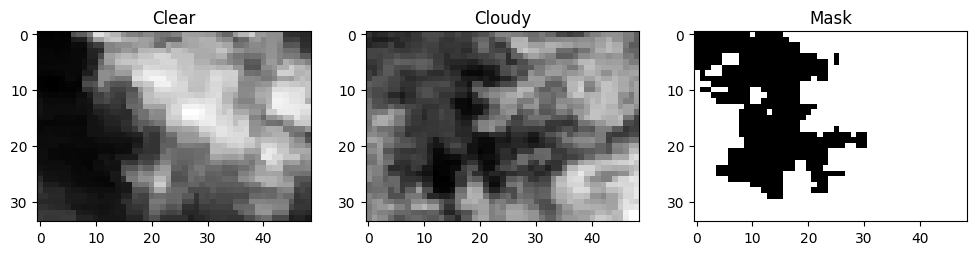

In [15]:
# Author: Samip Shrestha (2026)

import matplotlib.pyplot as plt

#### Clear

# Read the TIFF file
cloud = str(data["Cloudy"])
clear = str(data["Clear"])

tiff_path = f"gee_exports/clear2/{data['Satellite']}_{clear[:4]}-{clear[4:6]}-{clear[6:]}_{data['Latitude']}_{data['Longitude']}.tif"  # Replace with your file path

import rioxarray as rxr
import torch

# Load the raster
image = rxr.open_rasterio(tiff_path, masked=True)
image = torch.tensor(image.to_numpy())
print(tiff_path)
print(image.shape)
image = rxr.open_rasterio(tiff_path, masked=True)

# Get absolute min/max for band 'B2'
# (Assuming B2 is a coordinate or you've selected it)
b2_min = image.sel(band=3).min().item()
b2_max = image.sel(band=3).max().item()

print(f"Min: {b2_min}, Max: {b2_max}")
# Convert to numpy array for plotting (optional)
import numpy as np

clear = np.array(image.sel(band=3))


### Cloudy

tiff_path = f"gee_exports/cloudy2/{data['Satellite']}_{cloud[:4]}-{cloud[4:6]}-{cloud[6:]}_{data['Latitude']}_{data['Longitude']}.tif"  # Replace with your file path

import rioxarray as rxr
import torch

# Load the raster
image = rxr.open_rasterio(tiff_path, masked=True)
image = torch.tensor(image.to_numpy())
print(tiff_path)
print(image.shape)
image = rxr.open_rasterio(tiff_path, masked=True)

# Get absolute min/max for band 'B2'
# (Assuming B2 is a coordinate or you've selected it)
b2_min = image.sel(band=1).min().item()
b2_max = image.sel(band=1).max().item()

print(f"Min: {b2_min}, Max: {b2_max}")
# Convert to numpy array for plotting (optional)
import numpy as np

cloudy = np.array(image.sel(band=1))


### Cloud mask

# filelist = os.listdir('gee_exports/cloudmask/')
tiff_path = f"gee_exports/cloudmask2/{data['Satellite']}_{cloud[:4]}-{cloud[4:6]}-{cloud[6:]}_{data['Latitude']}_{data['Longitude']}.tif"  # Replace with your file path

import rioxarray as rxr
import torch

# Load the raster
image = rxr.open_rasterio(tiff_path, masked=True)
image = torch.tensor(image.to_numpy())
print(tiff_path)
print(image.shape)
image = rxr.open_rasterio(tiff_path, masked=True)

# Get absolute min/max for band 'B2'
# (Assuming B2 is a coordinate or you've selected it)
b2_min = image.sel(band=1).min().item()
b2_max = image.sel(band=1).max().item()

print(f"Min: {b2_min}, Max: {b2_max}")
# Convert to numpy array for plotting (optional)
import numpy as np

cloudmask = np.array(image.sel(band=1))

# Display the image
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(clear, cmap="gray" if clear.ndim == 2 else None)  # Use 'gray' for grayscale
axes[0].set_title("Clear")
axes[1].imshow(cloudy, cmap="gray" if cloudy.ndim == 2 else None)  # Use 'gray' for grayscale
axes[1].set_title("Cloudy")
axes[2].imshow(cloudmask, cmap="gray" if cloudmask.ndim == 2 else None)  # Use 'gray' for grayscale
axes[2].set_title("Mask")

print(np.unique(cloudmask))

# Methodology using geemap for observation and cloud cover 

In [16]:
!pip install geemap

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\marle\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\\LocalCache\\local-packages\\share\\jupyter\\labextensions\\@jupyter-widgets\\jupyterlab-manager\\static\\packages_base_lib_index_js-webpack_sharing_consume_default_jquery_jquery.5dd13f8e980fa3c50bfe.js'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\marle\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_q

Defaulting to user installation because normal site-packages is not writeable
  Using cached eerepr-0.1.2-py3-none-any.whl.metadata (4.2 kB)
  Using cached geocoder-1.38.1-py2.py3-none-any.whl.metadata (14 kB)
  Using cached ipyfilechooser-0.6.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached pandas-3.0.3-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached pyperclip-1.11.0-py3-none-any.whl.metadata (2.4 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached xyzservices-2026.3.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached future-1.0.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached ratelim-0.1.6-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached psutil-7.2.2-cp37-abi3-win_amd64.whl.metadata (22 kB)
  Using cached stack_data-0.6.3-py3-none-any.whl.metadata (18 kB)
  Using cached pure_eval-0.2.3-py3-

In [17]:
# For S2

import ee
import geemap

# 1. Define a point in the Swiss Alps (Eiger/Jungfrau region)
latitude = 56.19
longitude = -127.10
aoi = ee.Geometry.Point([longitude, latitude])

satname = "s2"

if satname == "s2" or satname == "landsat":
    ee_bbox = EEBoundingBox.from_centre(
        mid_lat=latitude,
        mid_lon=longitude,
        surrounding_metres=int(1000 / 2),  # Will export 1km x 1km
    )
    polygon = ee_bbox.to_ee_polygon()

collection = collection_list[satname]

# 2. Get the Sentinel-2 Collection
s2 = ee.ImageCollection(collection).filterBounds(aoi).filterDate("2024-11-01", "2024-12-20")

# 3. Get a "Cloudy" Sample (>80% clouds)
cloudy_img = s2.filter(ee.Filter.gt("CLOUDY_PIXEL_PERCENTAGE", 50)).first()

# 4. Get a "Clear" Sample (<5% clouds)
clear_img = s2.filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 10)).first()

print("cloudy:", cloudy_img.get("system:index").getInfo()[:8])
print("clear:", clear_img.get("system:index").getInfo()[:8])

# Visual Parameters (True Color)
vis_params = {"bands": ["B4", "B3", "B2"], "min": 0, "max": 3000}
# vis_params = {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 1}

# To display in a notebook (using geemap)
Map = geemap.Map()
Map.addLayer(cloudy_img, vis_params, "Cloudy Alps")
Map.addLayer(clear_img, vis_params, "Clear Alps")
Map.addLayer(polygon)
Map.centerObject(polygon, 12)
Map

62086.30020496687
-127.09194669358055 -127.10805330641944
cloudy: 20241102
clear: 20241122


Map(center=[56.1900000864691, -127.09999999997561], controls=(WidgetControl(options=['position', 'transparent_…

In [18]:
datainfo

,Latitude,Longitude,Cloudy,Clear,Satellite
0,46.628,8.326,20230608,20230625,s2
1,46.633,8.218,20230608,20230625,s2
2,46.680,8.650,20230608,20230625,s2
3,46.320,7.830,20220501,20220618,s2
4,27.884,86.333,20220502,20221024,s2
5,28.844,83.933,20231101,20231106,s2
6,28.855,84.165,20231101,20231106,s2
7,56.000,-127.100,20231203,20231210,s2
8,56.120,-127.230,20231203,20231210,s2
9,56.190,-127.100,20231203,20231210,s2


# Add new point if required from s2 or landsat

In [19]:
new_row = {
    "Cloudy": cloudy_img.get("system:index").getInfo()[:8],
    "Clear": clear_img.get("system:index").getInfo()[:8],
    "Latitude": latitude,
    "Longitude": longitude,
    "Satellite": satname,
}

# Append to existing dataframe
datainfo = pd.concat([datainfo, pd.DataFrame([new_row])], ignore_index=True)
datainfo.to_csv("Pointinfo.csv", index=None)

In [20]:
# For Landsat

import ee

latitude = 46.99
longitude = 11.94
aoi = ee.Geometry.Point([longitude, latitude])

satname = "Landsat"

if satname == "s2" or satname == "Landsat":
    ee_bbox = EEBoundingBox.from_centre(
        mid_lat=latitude,
        mid_lon=longitude,
        surrounding_metres=int(1000 / 2),  # Will export 1km x 1km
    )
    polygon = ee_bbox.to_ee_polygon()

collection = collection_list[satname]

# 2. Get the Sentinel-2 Collection
s2 = ee.ImageCollection(collection).filterBounds(aoi).filterDate("2022-03-01", "2025-12-20")


# 3. Get a "Cloudy" Sample (>80% clouds)
cloudy_img = s2.filter(ee.Filter.gt("CLOUD_COVER", 50)).first()

# 4. Get a "Clear" Sample (<5% clouds)
clear_img = s2.filter(ee.Filter.lt("CLOUD_COVER", 20)).first()

print("cloudy:", cloudy_img.get("system:index").getInfo()[-8:])
print("clear:", clear_img.get("system:index").getInfo()[-8:])

# Visual Parameters (True Color)
vis_params = {"bands": ["B4", "B3", "B2"], "min": 0, "max": 1}
# vis_params = {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 1}

# To display in a notebook (using geemap)
Map = geemap.Map()
Map.addLayer(cloudy_img, vis_params, "Cloudy Alps")
Map.addLayer(clear_img, vis_params, "Clear Alps")
Map.addLayer(polygon)
Map.centerObject(polygon, 12)
Map

76070.15889980328
11.946572879657824 11.933427120342175
cloudy: 20220422
clear: 20220305


Map(center=[46.99000006186863, 11.940000000019236], controls=(WidgetControl(options=['position', 'transparent_…

In [21]:
# For s3


import ee

# 1. Define a point in the Swiss Alps (Eiger/Jungfrau region)
latitude = data["Latitude"]
longitude = data["Longitude"]
aoi = ee.Geometry.Point([longitude, latitude])

satname = "s3"

if satname == "s3":
    ee_bbox = EEBoundingBox.from_centre(
        mid_lat=latitude,
        mid_lon=longitude,
        surrounding_metres=int(10000 / 2),  # Will export 1km x 1km
    )
    polygon = ee_bbox.to_ee_polygon()

collection = collection_list[satname]

cloud = str(data["Cloudy"])
clr = str(data["Clear"])
# 2. Get the Sentinel-2 Collection
s2 = (
    ee.ImageCollection(collection)
    .filterBounds(polygon)
    .filterDate(
        f"{cloud[:4]}-{cloud[4:6]}-{cloud[6:]}", f"{cloud[:4]}-{cloud[4:6]}-{int(cloud[6:]) + 1}"
    )
)
s3 = (
    ee.ImageCollection(collection)
    .filterBounds(polygon)
    .filterDate(f"{clr[:4]}-{clr[4:6]}-{clr[6:]}", f"{clr[:4]}-{clr[4:6]}-{int(clr[6:]) + 1}")
)
mask = get_cloud_mask(
    region=polygon,
    start_date=f"{cloud[:4]}-{cloud[4:6]}-{cloud[6:]}",
    end_date=f"{cloud[:4]}-{cloud[4:6]}-{int(cloud[6:]) + 1}",
    collection=satname,
)

# 3. Get a "Cloudy" Sample (>80% clouds)
# cloudy_img = s2.filter(ee.Filter.gt('CLOUDY_PIXEL_PERCENTAGE', 50)).first()

# 4. Get a "Clear" Sample (<5% clouds)
# clear_img = s2.filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10)).first()

# print("cloudy:",cloudy_img.get('system:index').getInfo()[:8])
# print("clear:",clear_img.get('system:index').getInfo()[:8])

# Visual Parameters (True Color)
# vis_params = {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 3000}
vis_params = {"bands": ["Oa08_radiance", "Oa06_radiance", "Oa04_radiance"], "min": 0, "max": 600}

# To display in a notebook (using geemap)
Map = geemap.Map()
Map.addLayer(s2.first(), vis_params, "Cloudy Alps")
Map.addLayer(s3.first(), vis_params, "Clear Alps")
Map.addLayer(mask.first(), {"min": 0, "max": 1}, "Cloud mask")
Map.addLayer(polygon)
Map.centerObject(polygon, 12)
Map

76582.2348048385
8.39128929343394 8.26071070656606


Map(center=[46.628006111002506, 8.326000000001265], controls=(WidgetControl(options=['position', 'transparent_…

In [22]:
# For MODIS

import ee

data = datainfo.iloc[31]
print(data)
# 1. Define a point in the Swiss Alps (Eiger/Jungfrau region)
latitude = data["Latitude"]
longitude = data["Longitude"]

cloud = data["Cloudy"]
clr = data["Clear"]

aoi = ee.Geometry.Point([longitude, latitude])

satname = "modis"

if satname == "viirs_coarse" or satname == "viirs_fine" or satname == "modis":
    ee_bbox = EEBoundingBox.from_centre(
        mid_lat=latitude,
        mid_lon=longitude,
        surrounding_metres=int(100000 / 2),  # Will export 100km x 100km
    )
    polygon = ee_bbox.to_ee_polygon()

collection = collection_list[satname]

cloud = str("20220303")
clr = str(data["Clear"])
# 2. Get the Sentinel-2 Collection
s2 = (
    ee.ImageCollection(collection)
    .filterBounds(aoi)
    .filterDate(
        f"{cloud[:4]}-{cloud[4:6]}-{cloud[6:]}", f"{cloud[:4]}-{cloud[4:6]}-{int(cloud[6:]) + 1}"
    )
)
s3 = (
    ee.ImageCollection(collection)
    .filterBounds(aoi)
    .filterDate(f"{clr[:4]}-{clr[4:6]}-{clr[6:]}", f"{clr[:4]}-{clr[4:6]}-{int(clr[6:]) + 1}")
)

# 3. Get a "Cloudy" Sample (>80% clouds)
# cloudy_img = s2.filter(ee.Filter.gt('CLOUDY_PIXEL_PERCENTAGE', 50)).first()

# 4. Get a "Clear" Sample (<5% clouds)
# clear_img = s2.filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10)).first()

# print("cloudy:",cloudy_img.get('system:index').getInfo()[:8])
# print("clear:",clear_img.get('system:index').getInfo()[:8])

# Visual Parameters (True Color)
# vis_params = {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 3000}
vis_params = {"bands": ["sur_refl_b01", "sur_refl_b04", "sur_refl_b03"], "min": -600, "max": 8000}

# To display in a notebook (using geemap)
Map = geemap.Map()
Map.addLayer(s2.first(), vis_params, "Cloudy Alps")
Map.addLayer(s3.first(), vis_params, "Clear Alps")
Map.addLayer(polygon)
Map.centerObject(polygon, 5)
Map

Latitude        25.77
Longitude     -102.52
Cloudy       20220303
Clear        20220305
Satellite       modis
Name: 31, dtype: object
100311.83323540831
-102.0215543192929 -103.01844568070709


Map(center=[25.77027666128593, -102.52000000000021], controls=(WidgetControl(options=['position', 'transparent…

In [23]:
datainfo.tail(20)

,Latitude,Longitude,Cloudy,Clear,Satellite
41,26.740,-105.320,20241102,20241122,viirs_fine
42,46.628,8.326,20241102,20241122,viirs_fine
43,47.110,12.230,20241102,20241122,viirs_fine
44,28.844,83.933,20241102,20241122,viirs_fine
45,27.850,82.450,20241102,20241122,viirs_fine
46,29.500,81.150,20241102,20241122,viirs_fine
47,29.820,85.270,20241102,20241122,viirs_fine
48,55.720,-126.610,20241102,20241122,viirs_fine
49,46.460,21.250,20241102,20241122,viirs_fine
50,56.120,-127.230,20241102,20241122,viirs_coarse


In [24]:
# For VIIRS

import ee
import geemap

data = datainfo.iloc[32]
print(data)
# 1. Define a point in the Swiss Alps (Eiger/Jungfrau region)
latitude = data["Latitude"]
longitude = data["Longitude"]

latitude = 46.46
longitude = 21.25

cloud = data["Cloudy"]
clr = data["Clear"]

aoi = ee.Geometry.Point([longitude, latitude])

satname = "viirs_fine"

if satname == "viirs_coarse" or satname == "viirs_fine" or satname == "modis":
    ee_bbox = EEBoundingBox.from_centre(
        mid_lat=latitude,
        mid_lon=longitude,
        surrounding_metres=int(100000 / 2),  # Will export 100km x 100km
    )
    polygon = ee_bbox.to_ee_polygon()

collection = collection_list[satname]

cloud = str(data["Cloudy"])
clr = str(data["Clear"])
# 2. Get the Sentinel-2 Collection
s2 = (
    ee.ImageCollection(collection)
    .filterBounds(aoi)
    .filterDate(
        f"{cloud[:4]}-{cloud[4:6]}-{cloud[6:]}", f"{cloud[:4]}-{cloud[4:6]}-{int(cloud[6:]) + 1}"
    )
)
s3 = (
    ee.ImageCollection(collection)
    .filterBounds(aoi)
    .filterDate(f"{clr[:4]}-{clr[4:6]}-{clr[6:]}", f"{clr[:4]}-{clr[4:6]}-{int(clr[6:]) + 1}")
)

# 3. Get a "Cloudy" Sample (>80% clouds)
# cloudy_img = s2.filter(ee.Filter.gt('CLOUDY_PIXEL_PERCENTAGE', 50)).first()

# 4. Get a "Clear" Sample (<5% clouds)
# clear_img = s2.filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10)).first()

# print("cloudy:",cloudy_img.get('system:index').getInfo()[:8])
# print("clear:",clear_img.get('system:index').getInfo()[:8])

# Visual Parameters (True Color)
# vis_params = {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 3000}
vis_params = {"bands": ["M5", "M4", "M3"], "min": 0, "max": 1}

# To display in a notebook (using geemap)
Map = geemap.Map()
Map.addLayer(s2.first(), vis_params, "Cloudy Alps")
Map.addLayer(s3.first(), vis_params, "Clear Alps")
Map.addLayer(polygon)
Map.centerObject(polygon, 8)
Map

Latitude       46.628
Longitude       8.326
Cloudy       20220422
Clear        20220305
Satellite       modis
Name: 32, dtype: object
76818.83819877874
21.900882012438387 20.599117987561613


Map(center=[46.46060731476375, 21.250000000000096], controls=(WidgetControl(options=['position', 'transparent_…

# Location & Time Specifications

# Region size
For S2, S3 and landsat we use 1 km x 1km size bounding box
For MODIS & VIIRS we utilize larger 100km x 100km size bounding box

# Sensor Specification
(uncomment the sensor that should be exported)

In [25]:
if satname == "s2":
    img, sensor = get_single_s2_image(
        region=polygon, start_date=cur_date, end_date=cur_date + timedelta(days=1)
    )
if satname == "landsat":
    img, sensor = get_single_landsat_image(
        region=polygon, start_date=cur_date, end_date=cur_date + timedelta(days=1)
    )
if satname == "s3":
    img, sensor = get_single_s3_image(
        region=polygon, start_date=cur_date, end_date=cur_date + timedelta(days=1)
    )
if satname == "modis":
    img, sensor = get_single_modis_image(
        region=polygon, start_date=cur_date, end_date=cur_date + timedelta(days=1)
    )
if satname == "viirs_fine":
    img, sensor = get_single_viirs_fine_image(
        region=polygon, start_date=cur_date, end_date=cur_date + timedelta(days=1)
    )
if satname == "viirs_coarse":
    img, sensor = get_single_viirs_coarse_image(
        region=polygon, start_date=cur_date, end_date=cur_date + timedelta(days=1)
    )

# Cloud mask algorithms

In [26]:
# 1. Sentinel-2 Harmonized (QA60 Band)
def mask_s2(image):
    qa = image.select("QA60")
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    return mask


# 2. Landsat 8 TOA (QA_PIXEL Band)
def mask_l8(image):
    qa = image.select("QA_PIXEL")
    # Bit 3: Cloud, Bit 4: Cloud Shadow
    mask = qa.bitwiseAnd(1 << 3).eq(0).And(qa.bitwiseAnd(1 << 4).eq(0))
    return mask


# 3. MODIS (state_1km Band)
def mask_modis(image):
    qa = image.select("state_1km")
    # Bits 0-1: Cloud state (0 is clear)
    mask = qa.bitwiseAnd(3).eq(0)
    return mask


# 4. VIIRS Coarse (StatePriv Band)
def mask_viirs(image):
    qa = image.select("StatePriv")
    # Bits 0-1: Cloud state (0 is clear)
    mask = qa.bitwiseAnd(3).eq(0)
    return mask


# 5. Sentinel-3 OLCI (quality_flags)
def mask_s3(image):
    qa = image.select("quality_flags")
    # Bit 27: Cloud
    mask = qa.bitwiseAnd(1 << 27).eq(0)
    return mask

In [27]:
data = datainfo.iloc[2]
data

Latitude        46.68
Longitude        8.65
Cloudy       20230608
Clear        20230625
Satellite          s2
Name: 2, dtype: object

In [28]:
!pip install --upgrade earthengine-api geemap

Defaulting to user installation because normal site-packages is not writeable
  Using cached earthengine_api-1.7.31-py3-none-any.whl.metadata (2.2 kB)
  Using cached geemap-0.38.1-py3-none-any.whl.metadata (14 kB)
  Using cached google_cloud_storage-3.12.0-py3-none-any.whl.metadata (15 kB)
  Using cached google_api_python_client-2.197.0-py3-none-any.whl.metadata (7.0 kB)
  Using cached google_auth-2.55.0-py3-none-any.whl.metadata (5.1 kB)
  Using cached google_auth_httplib2-0.4.0-py3-none-any.whl.metadata (3.0 kB)
  Using cached httplib2-0.31.2-py3-none-any.whl.metadata (2.2 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached anywidget-0.11.0-py3-none-any.whl.metadata (8.9 kB)
  Using cached bqplot-0.13.1-py2.py3-none-any.whl.metadata (5.0 kB)
  Using cached eerepr-0.1.2-py3-none-any.whl.metadata (4.2 kB)
  Using cached folium-0.20.0-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached geocoder-1.38.1-py2.py3-none-any.whl.metadata (14 kB)
  Using cache

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

# Exploring cloud mask

In [29]:
import geemap

latitude = data["Latitude"]
longitude = data["Longitude"]

cloud = data["Cloudy"]
clr = data["Clear"]

aoi = ee.Geometry.Point([longitude, latitude])

satname = data["Satellite"]

if satname == "viirs_coarse" or satname == "viirs_fine" or satname == "modis":
    ee_bbox = EEBoundingBox.from_centre(
        mid_lat=latitude,
        mid_lon=longitude,
        surrounding_metres=int(100000 / 2),  # Will export 100km x 100km
    )
    polygon = ee_bbox.to_ee_polygon()

collection = collection_list[satname]

cloud = str(data["Cloudy"])
# 2. Get the Sentinel-2 Collection
image = (
    ee.ImageCollection(collection)
    .filterBounds(polygon)
    .filterDate(
        f"{cloud[:4]}-{cloud[4:6]}-{cloud[6:]}", f"{cloud[:4]}-{cloud[4:6]}-{int(cloud[6:]) + 1}"
    )
)

mask = get_cloud_mask(
    region=polygon,
    start_date=f"{cloud[:4]}-{cloud[4:6]}-{cloud[6:]}",
    end_date=f"{cloud[:4]}-{cloud[4:6]}-{int(cloud[6:]) + 1}",
    collection=satname,
)

visparams = vispm[satname]
Map = geemap.Map()
Map.addLayer(image.first(), visparams, "Image")
Map.addLayer(mask.first(), {"min": 0, "max": 1}, "Cloud mask")
Map.addLayer(polygon)
Map.centerObject(polygon, 8)
Map

Map(center=[46.46060731476375, 21.250000000000096], controls=(WidgetControl(options=['position', 'transparent_…

In [30]:
print(ee.__version__)
print(geemap.__version__)

1.7.17
0.37.1
